# Stochastic Expectation-Maximization


In [1]:
%load_ext autoreload
%autoreload 2
from functools import cache
import importlib
import scipy.special as ss
import functools
import xgi
import math
from collections import Counter, defaultdict
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem", "src") 
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np
import pickle

plt.style.use('seaborn-v0_8-whitegrid')

Gtypes = ["orig", "PA", "ER", "PA_exact", "ER_exact"]
realworld_Hgraphs = ["coauth-dblp", "coauth-mag-geology", "coauth-mag-history", "dawn", "disgenenet",
                     "diseasome", "kaggle-whats-cooking", "ndc-classes", "ndc-substances",
                     "tags-ask-ubuntu", "tags-math-sx" , "tags-stack-overflow", "threads-ask-ubuntu", 
                     "threads-math-sx", "threads-stack-overflow",
                     "congress-bills", "contact-high-school", "contact-primary-school",
                     "email-enron", "email-eu", "hospital-lyon", "hypertext-conference", 
                     "invs13", "invs15",  "malawi-village", "science-gallery", "sfhh-conference"]

num_nodes = ["1,930,378", "1,261,129", "1,034,876", "2,558", "12,368", "516", "6,714", "1,161", "5,556",
            "3,029", "1,629", "49,998", "125,602", "176,445", "2,675,969",
            "1,718", "327", "242", "148", "1,005", "75", "113", "92", "232", "86", "10,972", "403"]

num_edges = ["3,700,681", "1,590,335", "1,812,511", "2,272,433", "2,261", "903", "39,774", "49,726", "112,405",
            "271,233", "822,059", "14,458,875", "192,947", "719,792", "11,305,356",
            "282,049", "172,035", "106,879", "10,885", "235,263", "27,834", "19,036",
            "9,644", "73,822", "99,942", "338,765", "54,305"]

num_edges = [int(x.replace(',', '')) for x in num_edges]
timestamp_dict = dict(zip(realworld_Hgraphs, num_edges))



C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\utils\utilities.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


not finished or errors
not finished or errors
not finished or errors


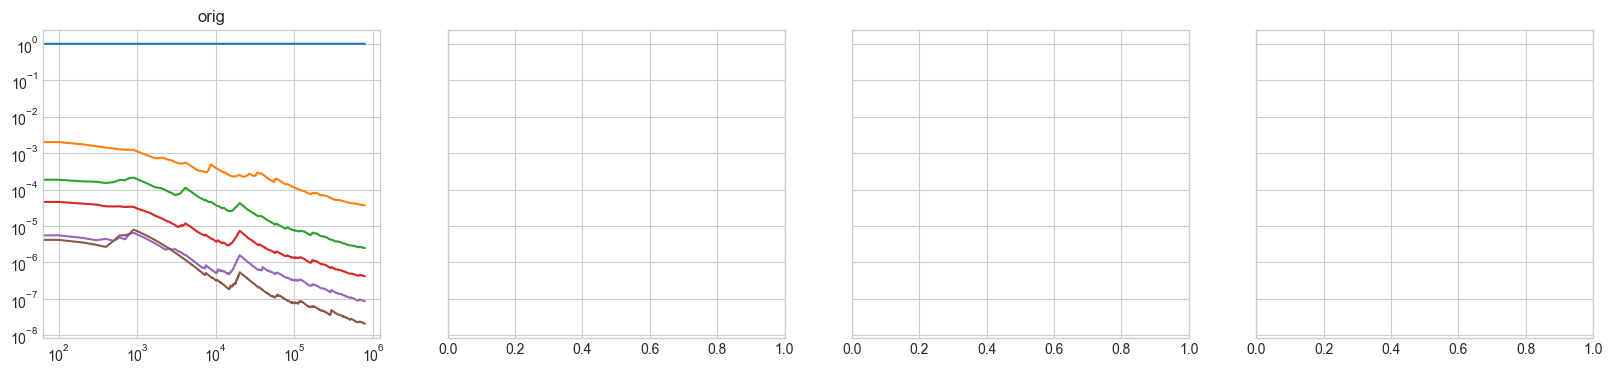

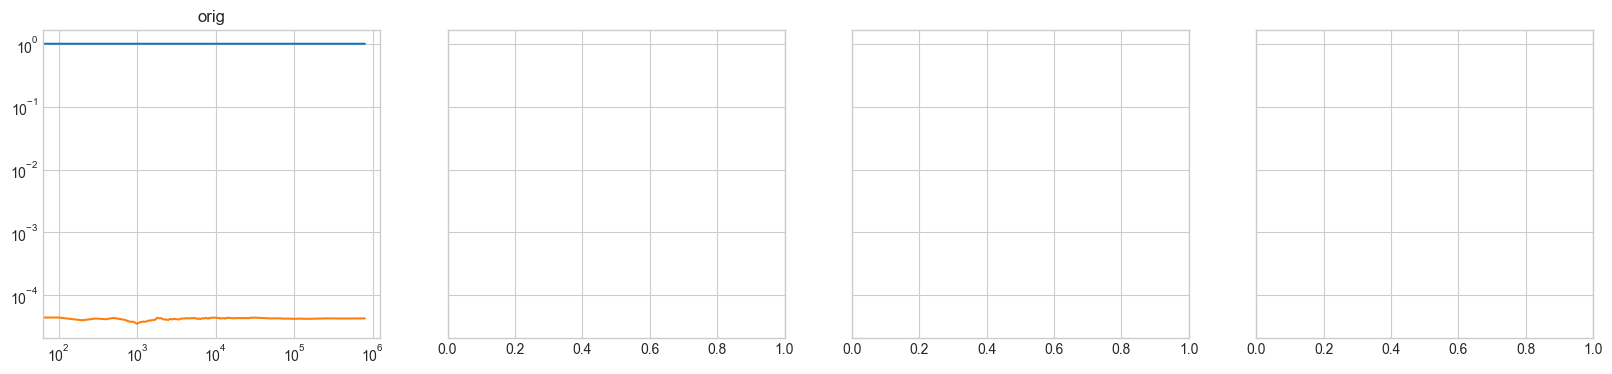

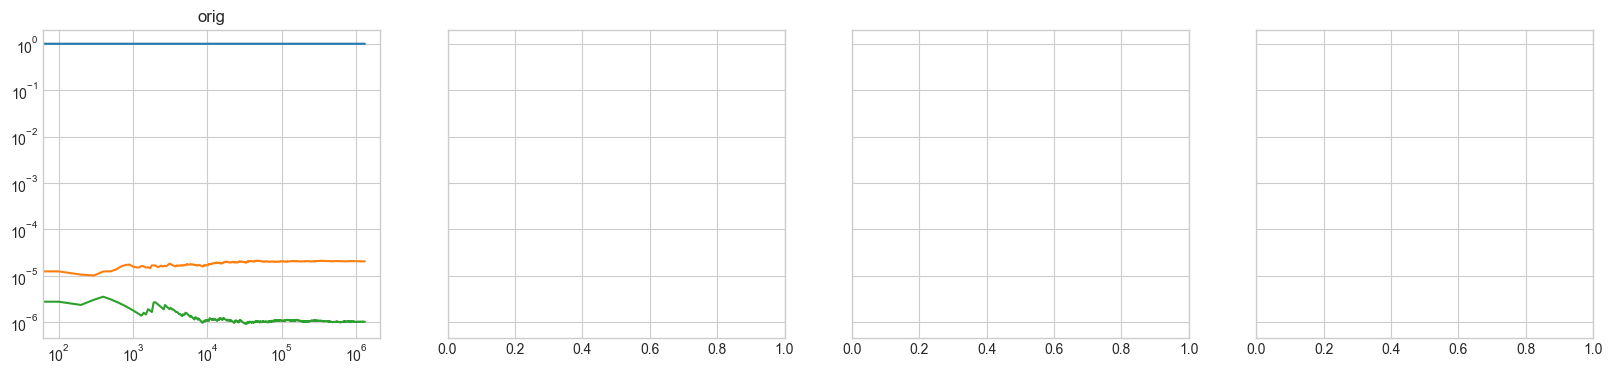

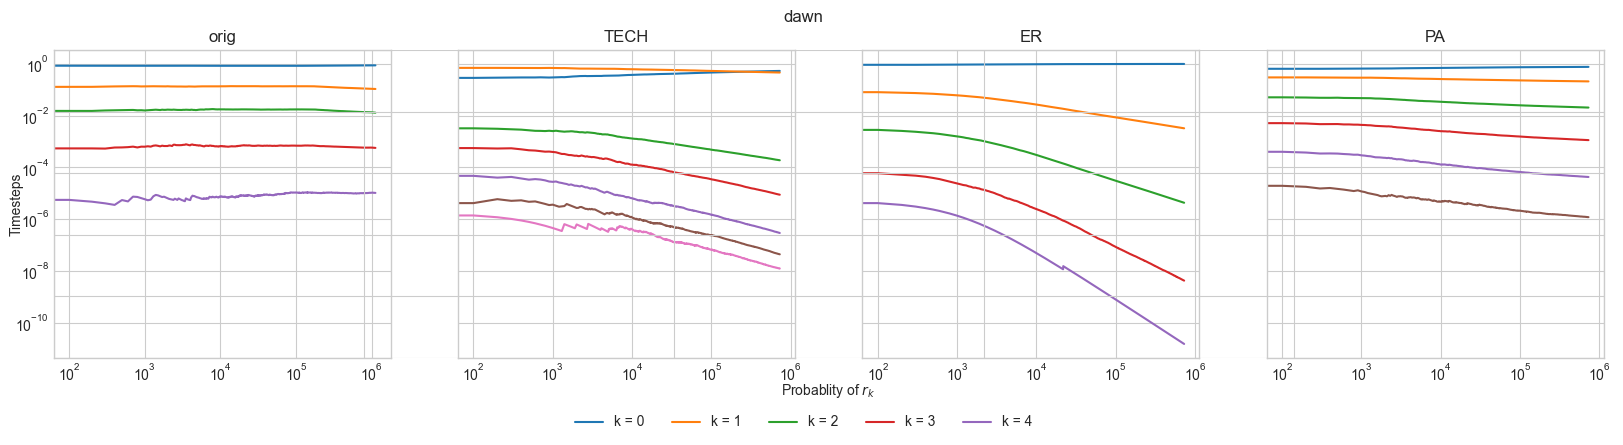

not finished or errors
not finished or errors


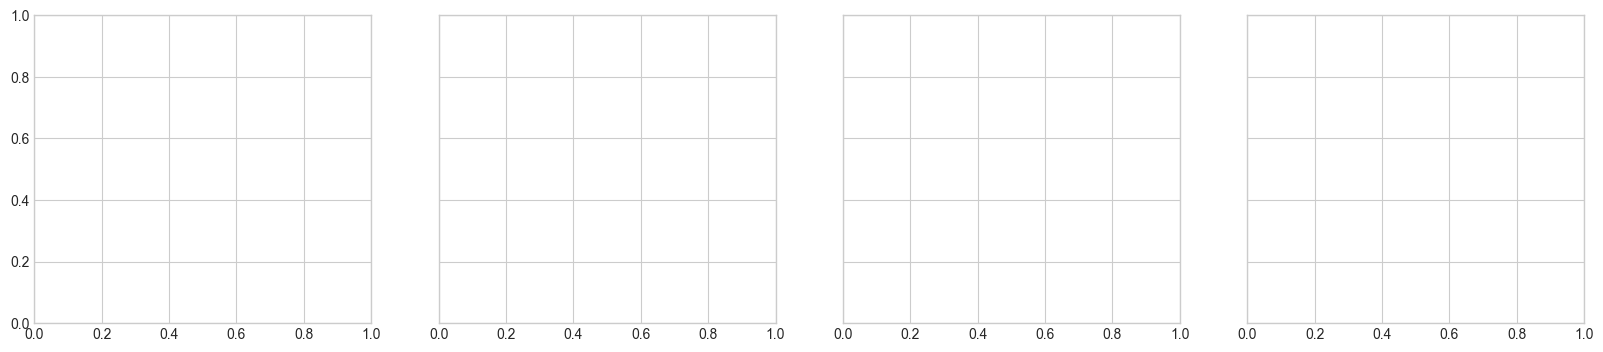

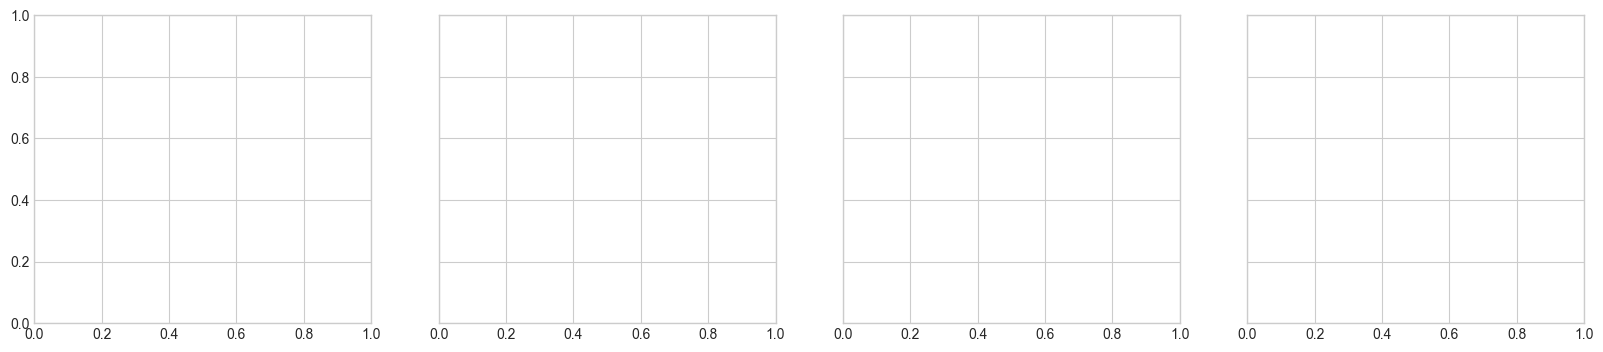

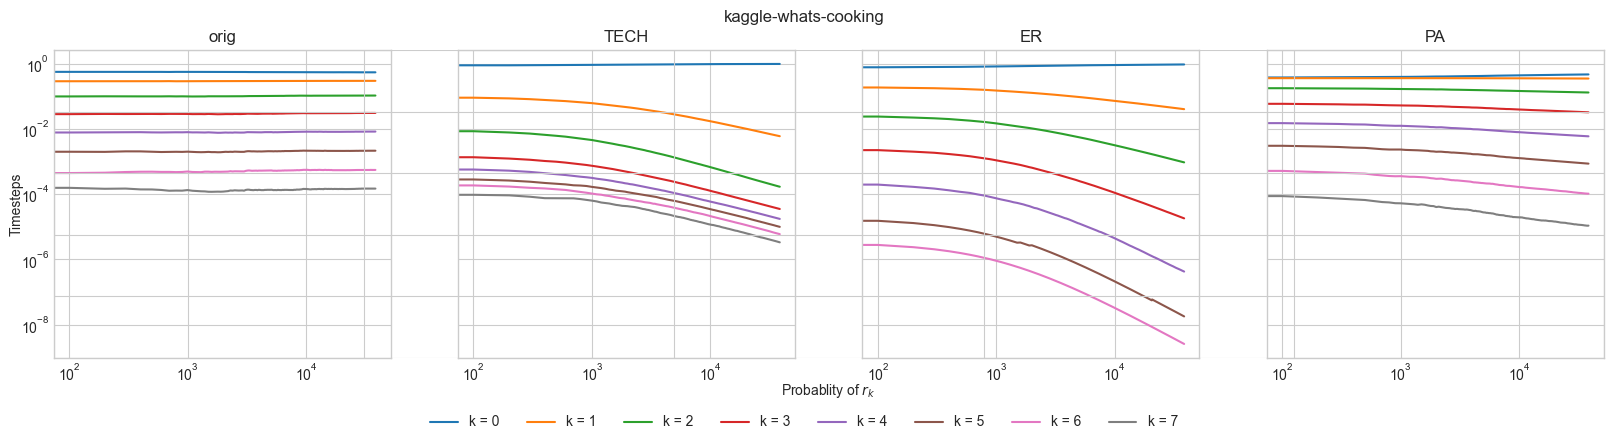

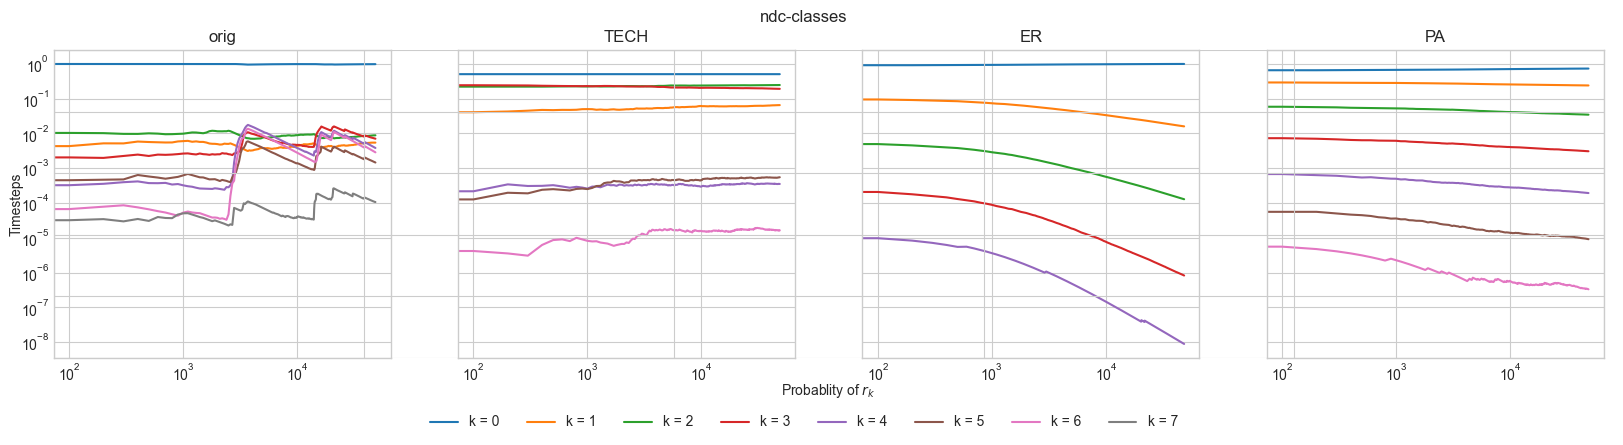

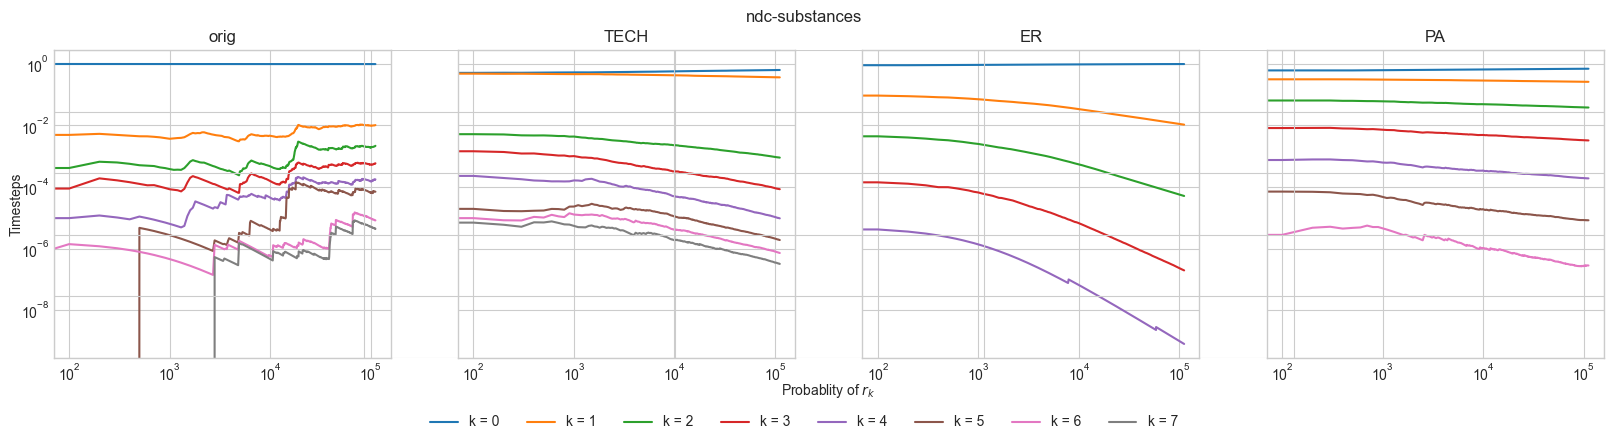

not finished or errors
not finished or errors
not finished or errors


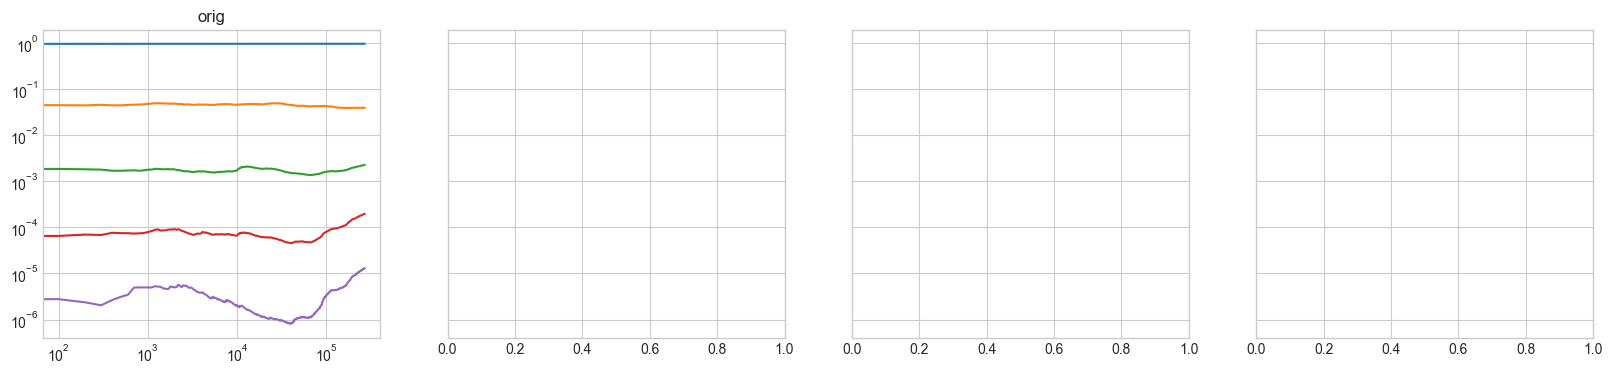

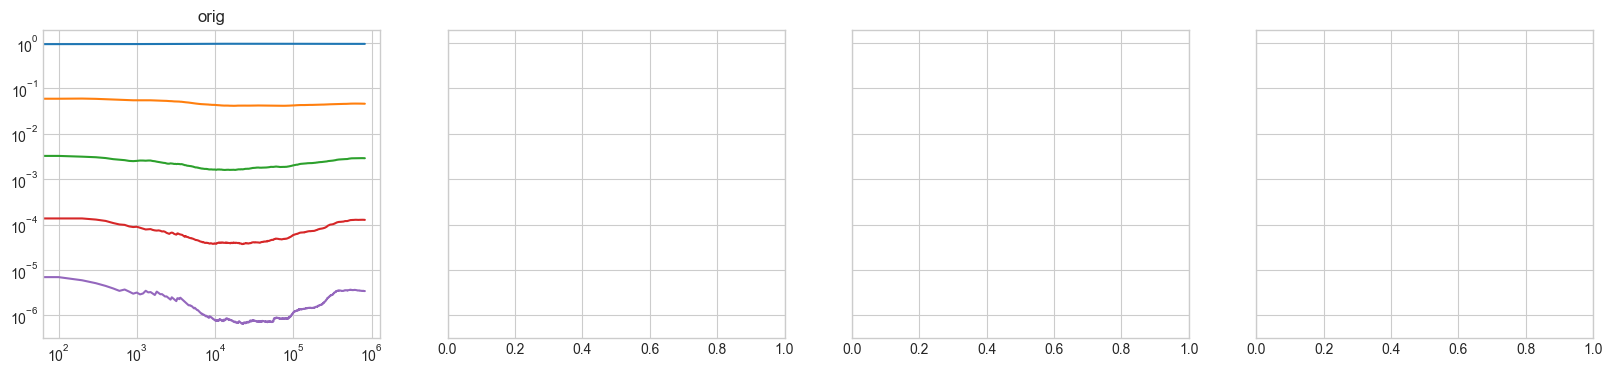

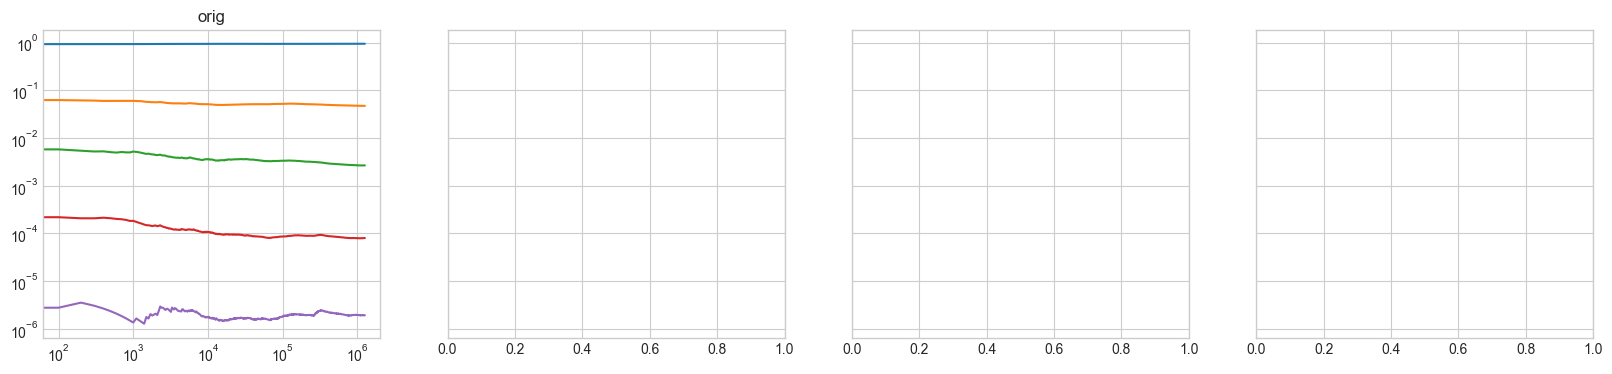

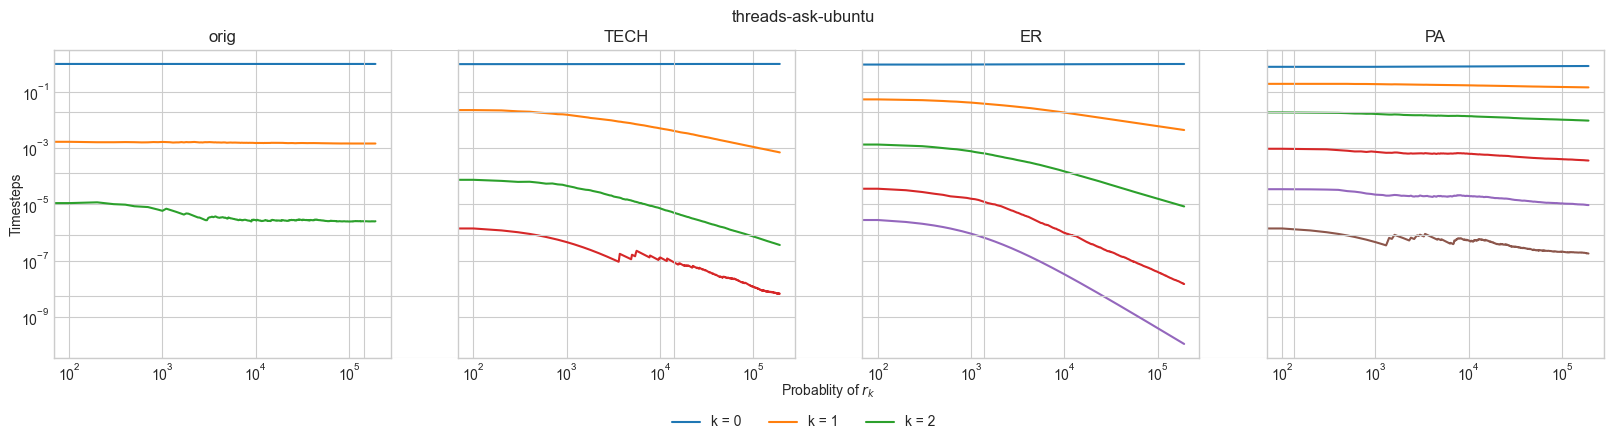

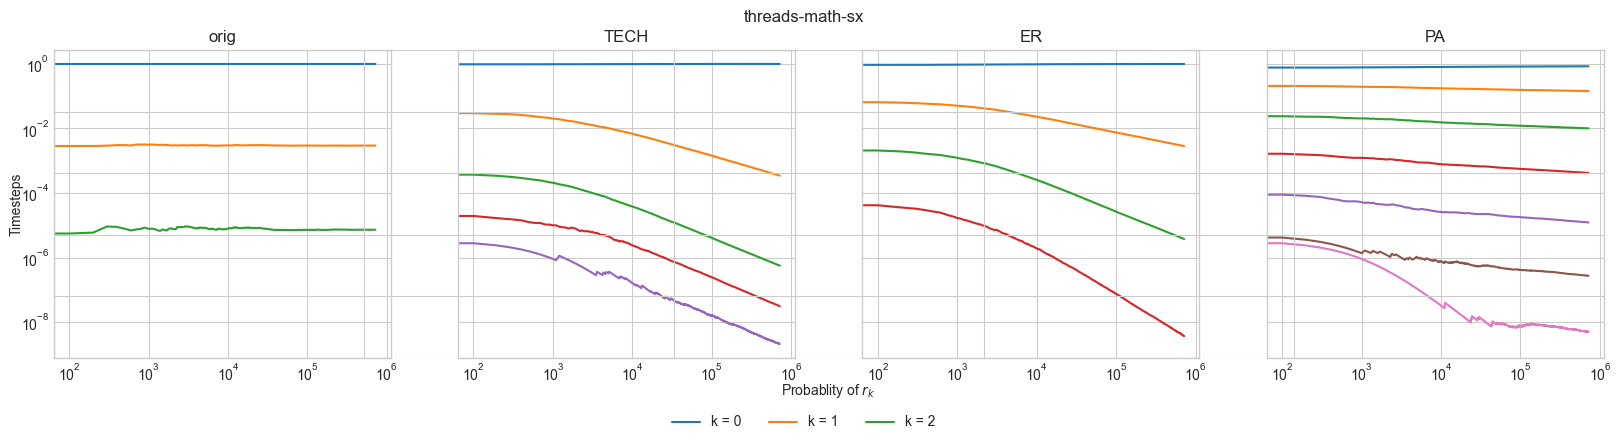

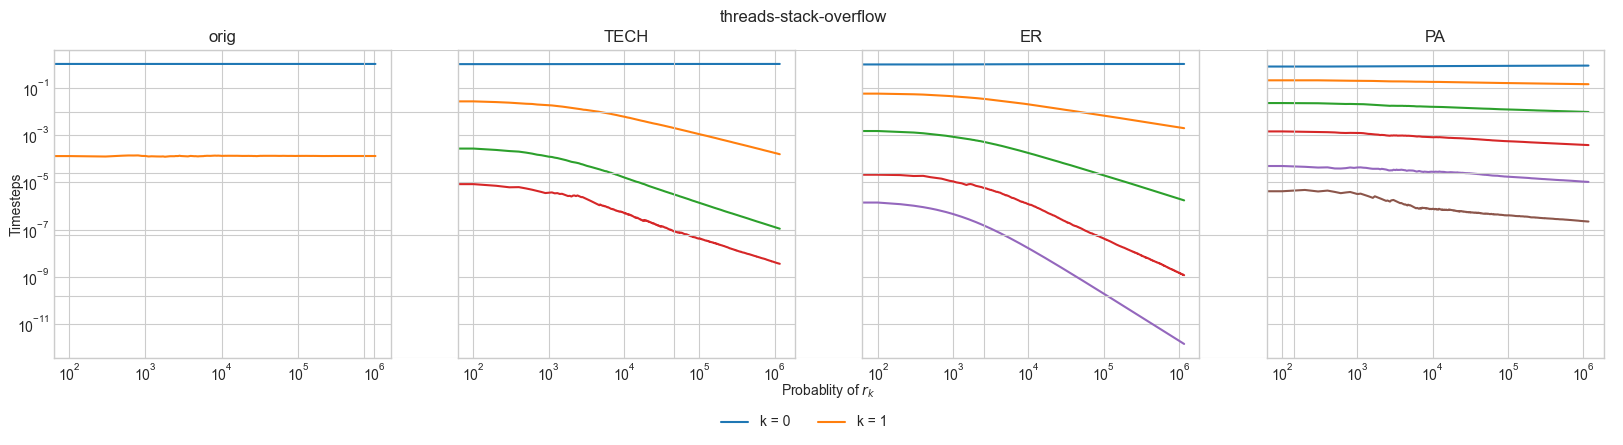

not finished or errors


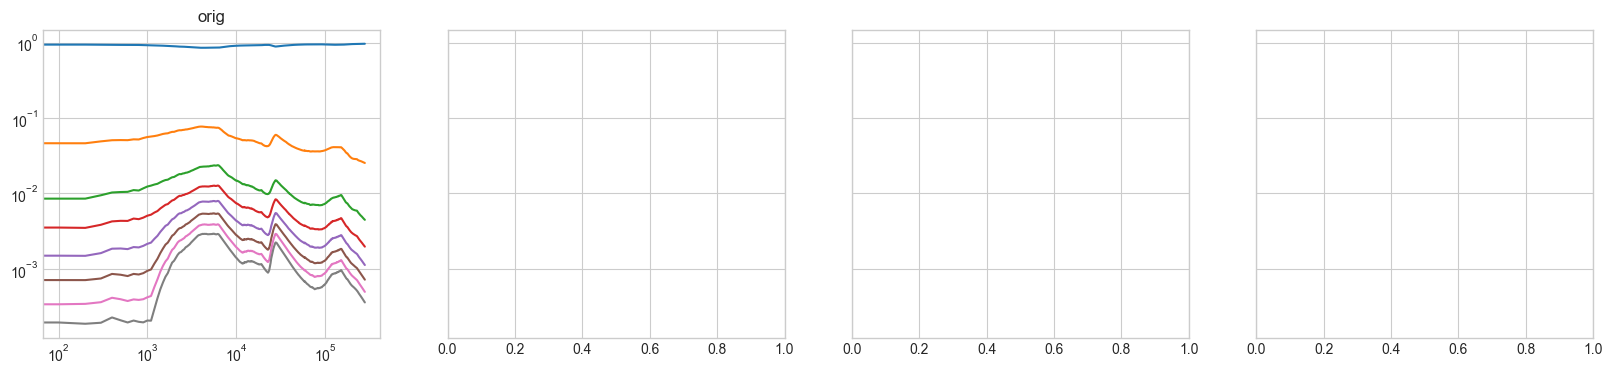

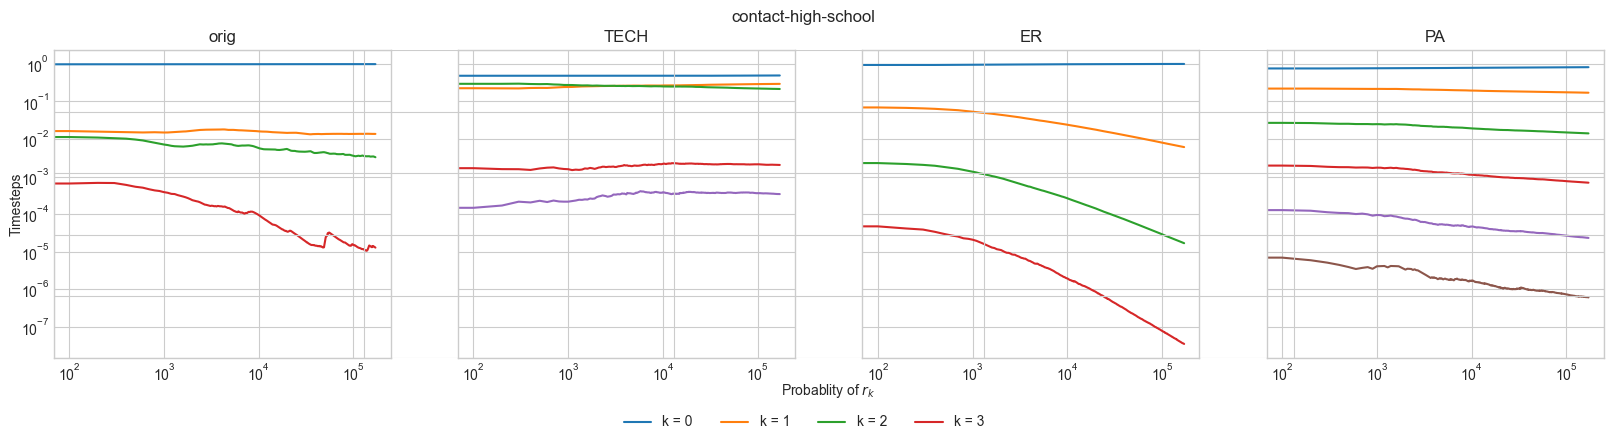

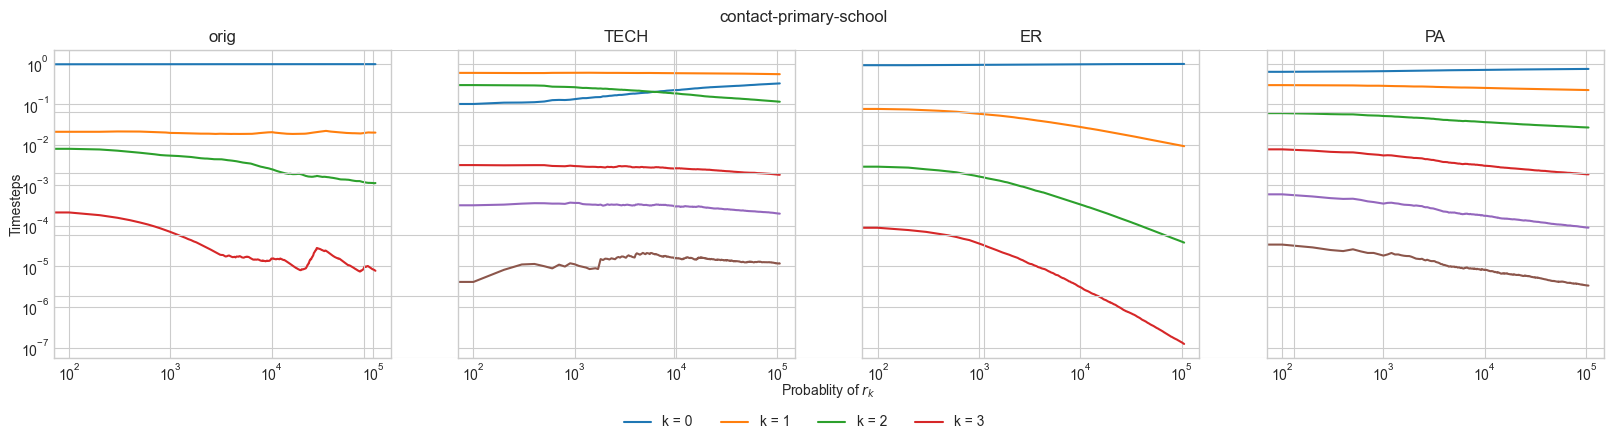

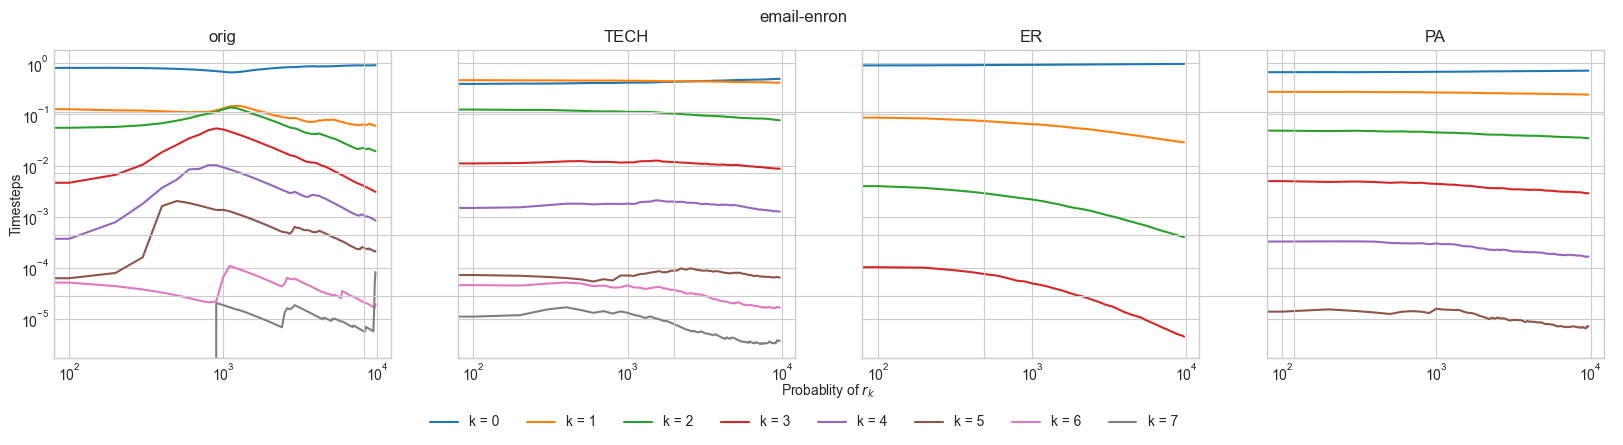

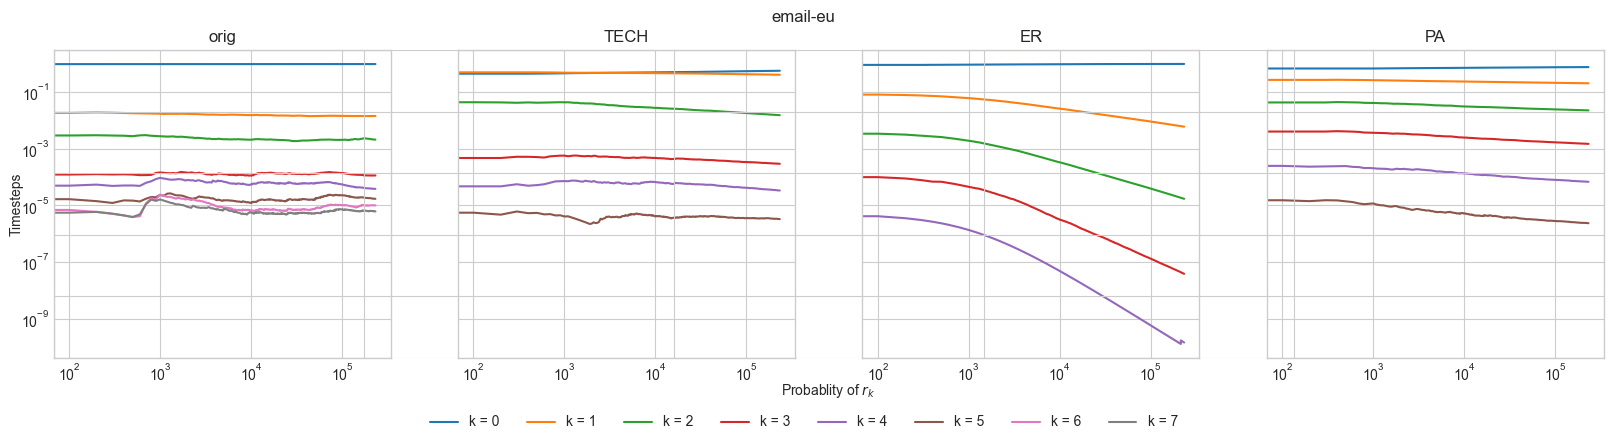

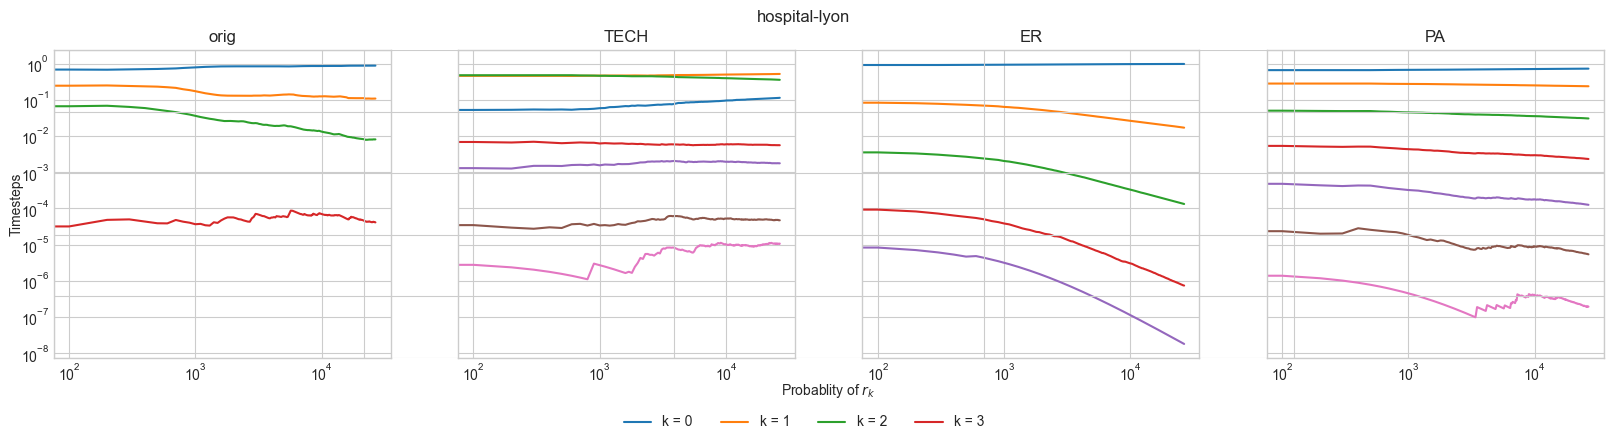

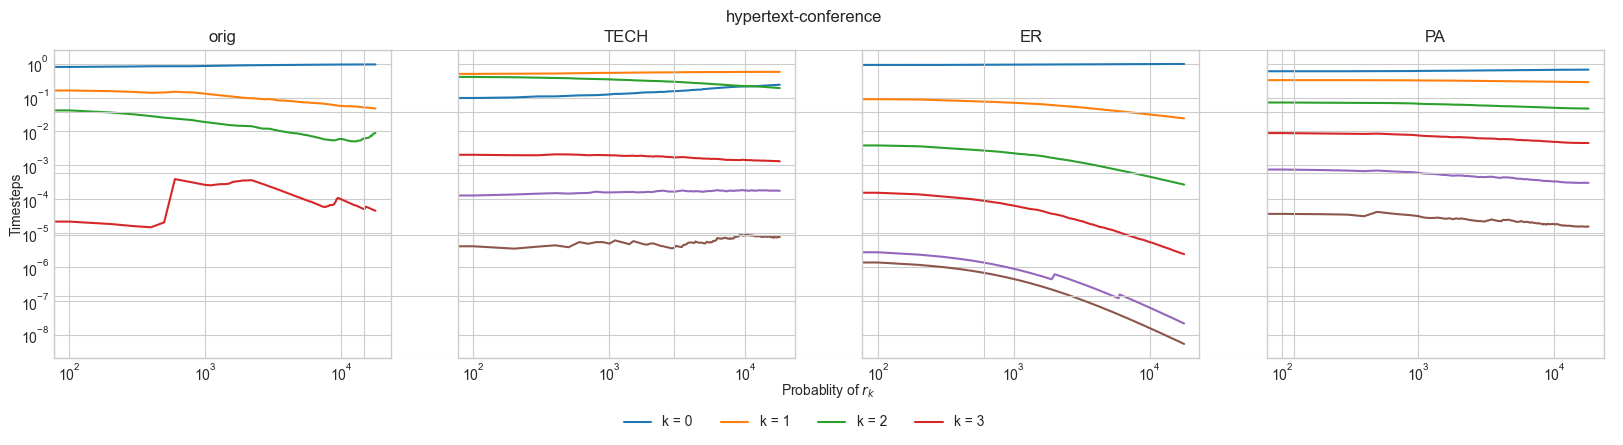

not finished or errors


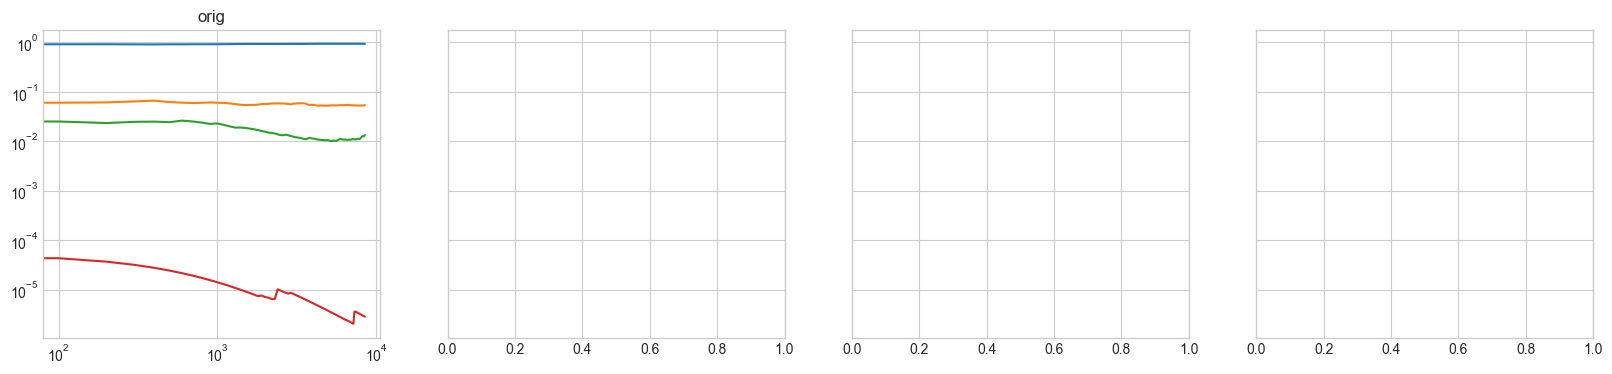

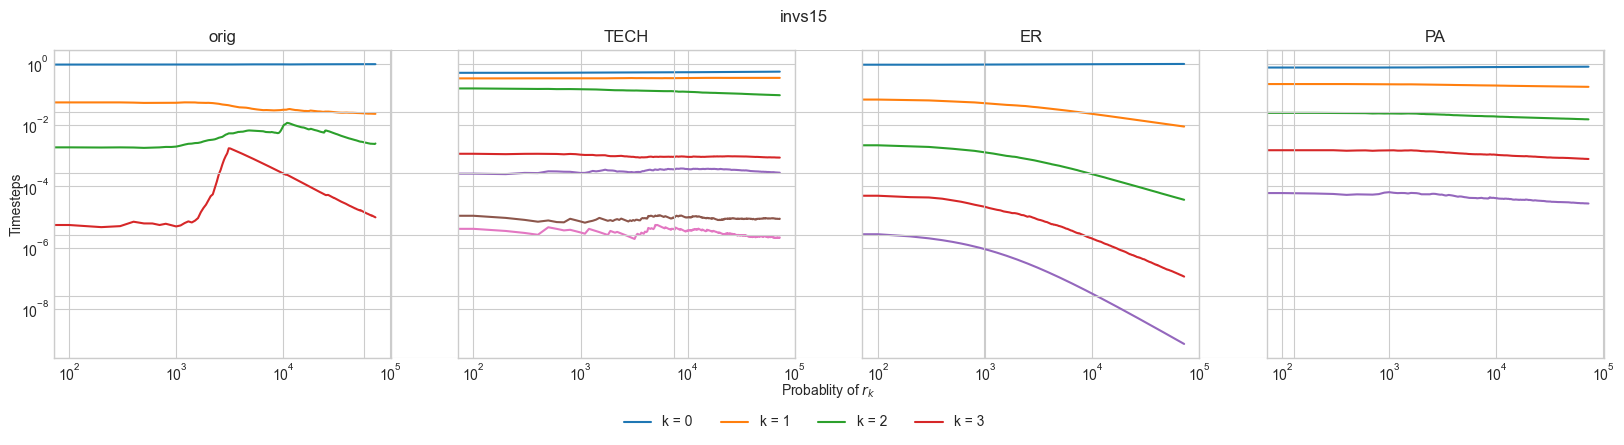

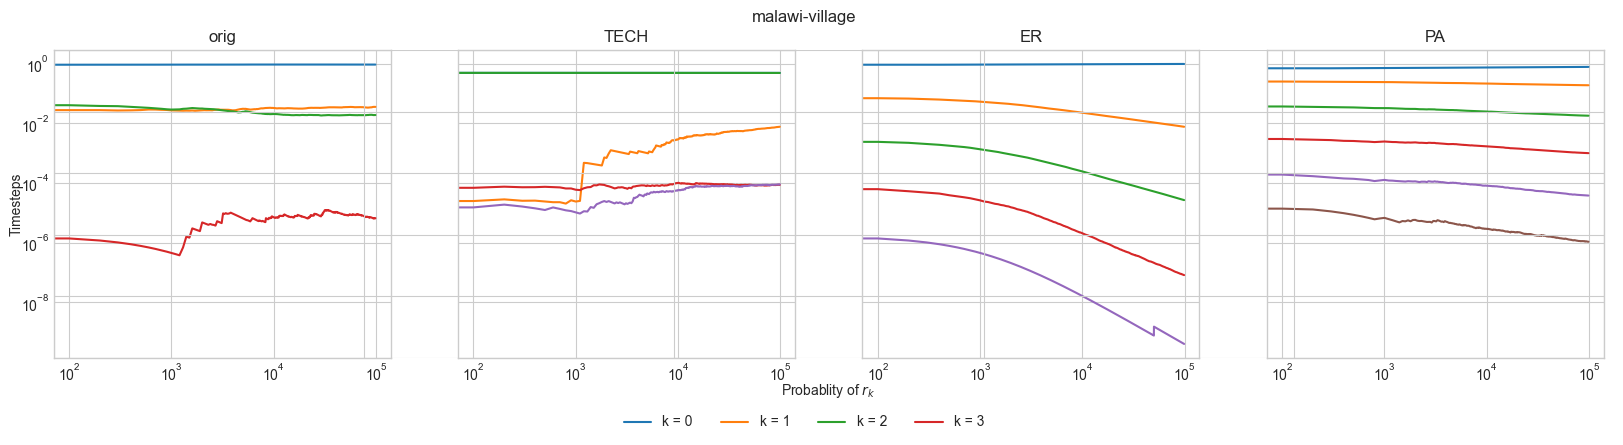

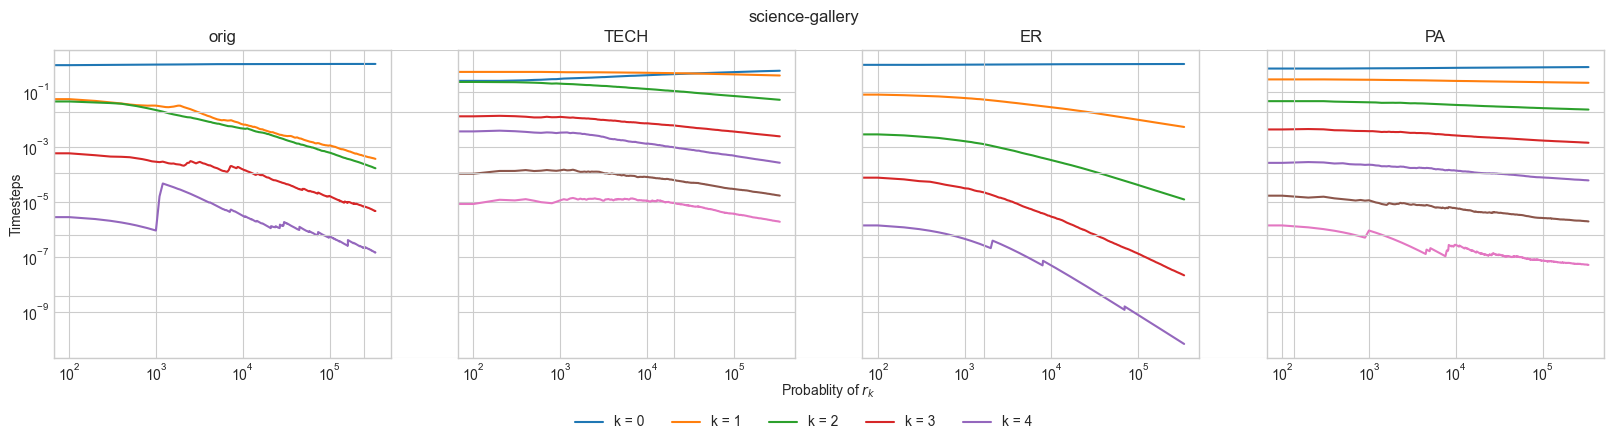

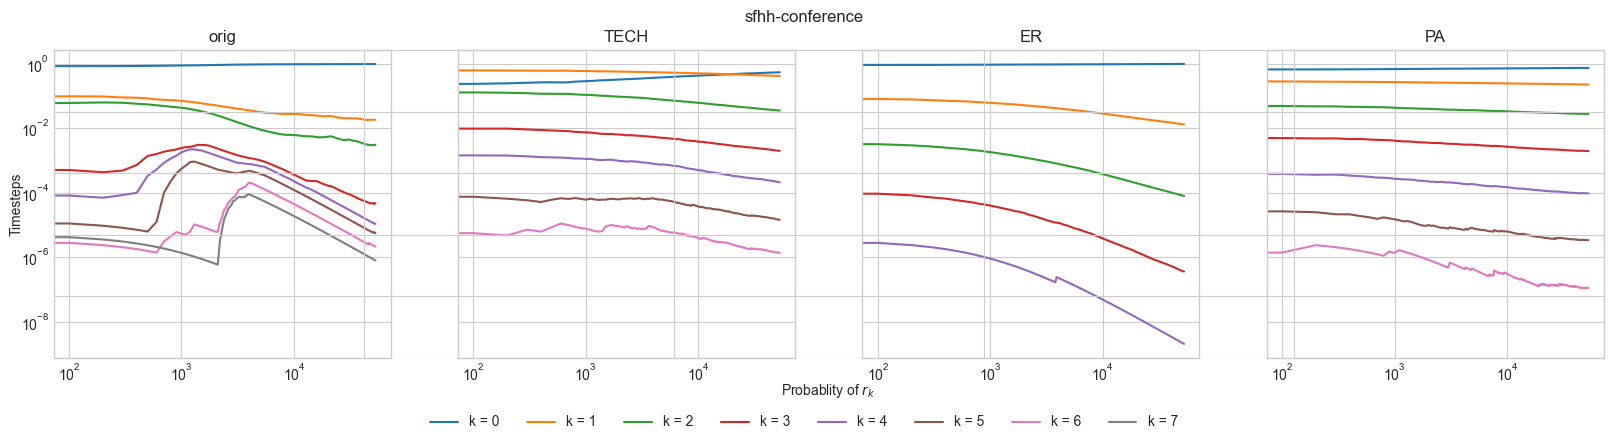

In [29]:

#data = "ndc-substances"
for data in realworld_Hgraphs:


    try:
        gplot = ["orig", "TECH", "ER", "PA"]
        timesteps = timestamp_dict[data]


        fig, axes = plt.subplots(nrows= 1, ncols= len(gplot), figsize=(20, 4), sharey=True)

        for i, ax in enumerate(axes):

            if i == 0:
                toplot = np.load('simulation_results_realworld/' + data + '_' + gplot[i] + ".npy", allow_pickle=True) 
            else:
                toplot = np.load('simulation_results_recovered/' + data + '_' + gplot[i] + ".npy", allow_pickle=True) 

            #print(len(toplot[10]))

            topk_value = min(8, len(toplot[10]))

            for j in range(0, topk_value):
                k0 = [x[j] for x in toplot[10:]] 
                # 0.01 is used to offset 0s in the intersection sizes to avoid loglog failures
                ax.plot([x*100 for x in range(len(toplot[10:]))], k0, label = "k = " + str(j))
            #if i == 0:
            #    ax.legend(ncols= 3, loc = 'upper center')
            ax.set_title(gplot[i])
            ax.loglog()
            #ax.set_xscale('symlog')
            #ax.set_yscale('symlog')

        fig.suptitle(data)

        fig.add_subplot(111, frameon=False)
        # hide tick and tick label of the big axis

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.5, -0.1), ncol = 8)

        plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
        plt.xlabel("Probablity of $r_{k}$")
        plt.ylabel("Timesteps")
        plt.savefig("figures/realworld_intersection/{}_summarize_top5.pdf".format(data),  bbox_inches='tight')


        plt.show()
        plt.close()
    except:
        print("too big did not finish or errors")

